In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [10]:
#Load Dataset 
df = pd.read_csv("house_price.csv")
print(df.head())

   area  bedrooms  bathrooms  floors   age     price
0  1200       2.0          1     1.0  10.0   4200000
1  1500       3.0          2     1.0   NaN   6500000
2  1800       3.0          2     2.0   8.0   7200000
3  2400       NaN          3     2.0   3.0  10500000
4  3000       4.0          3     NaN   2.0  13500000


In [11]:
#check the data

print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       20 non-null     int64  
 1   bedrooms   18 non-null     float64
 2   bathrooms  20 non-null     int64  
 3   floors     16 non-null     float64
 4   age        19 non-null     float64
 5   price      20 non-null     int64  
dtypes: float64(3), int64(3)
memory usage: 1.1 KB
None
area         0
bedrooms     2
bathrooms    0
floors       4
age          1
price        0
dtype: int64


In [12]:
df = df.dropna()   # simple method

In [13]:
X = df[['area', 'bedrooms', 'bathrooms']]  # features
y = df['price']  # target

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 311832.40097678185


In [19]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())
results.to_csv("predictions.csv", index=False)

      Actual     Predicted
18  12000000  1.253002e+07
15   3000000  2.994372e+06
0    4200000  4.303744e+06


In [20]:
import joblib
joblib.dump(model, "linear_model.pkl")

['linear_model.pkl']

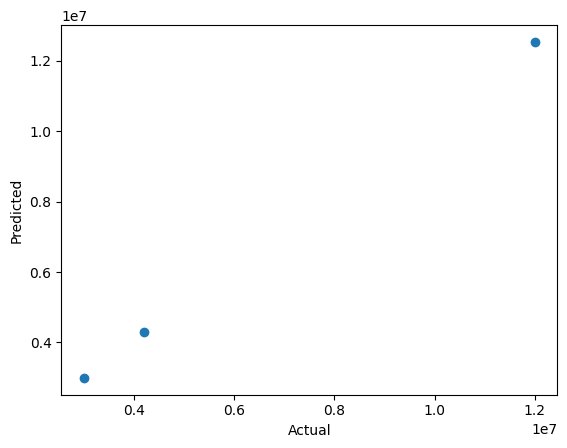

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()